# Elektrik Dağıtım Şebekelerinde Uçtan Uca Kaçak Tüketim (Anomali) Tespiti

**Amaç:** Abonelerin günlük elektrik tüketim zaman serilerini analiz ederek teknik olmayan kayıpları (kaçak kullanım) makine öğrenmesiyle tespit etmek ve saha denetim ekipleri için **risk skoru** üreten bir karar destek çıktısı sunmak.

**Veri seti:** State Grid Corporation of China (SGCC) - 42.372 abone, 01.01.2014–31.10.2016 arası günlük tüketim, `FLAG` (1 = kaçak).
Kaynak: [Kaggle – SGCC Electricity Theft Detection](https://www.kaggle.com/datasets/bensalem14/sgcc-dataset)

**Yöntem özeti**
1. **Ön işleme:** Eksik günler her abonenin *kendi* zaman serisi boyunca lineer interpolasyonla dolduruldu; aşırı uç değerler abone bazında (ortalama + 3σ) sınırlandı. Tüm adımlar satır bazlı olduğu için train/test arasında sızıntı yoktur.
2. **Özellik mühendisliği:** Ham günlük tüketime ek olarak aylık ortalamalar, değişkenlik, sıfır/eksik gün oranı, trend eğimi, ani düşüş sayısı gibi yorumlanabilir özellikler üretildi.
3. **Dengesiz veri:** SMOTE ve XGBoost `scale_pos_weight` yaklaşımları validasyon setinde karşılaştırıldı.
4. **Model:** XGBoost. Model seçimi ve karar eşiği validasyon setinde yapıldı; test seti yalnızca son değerlendirmede kullanıldı.
5. **Değerlendirme:** Accuracy yerine PR-AUC, ROC-AUC, Precision/Recall ve saha senaryosunu yansıtan **Precision@k** ve kümülatif kazanç (lift) eğrisi.
6. **Açıklanabilirlik:** SHAP ile genel özellik etkileri ve tek bir abone için karar açıklaması.

## 0. Kurulum ve ayarlar
Veri seti, ayarlar hücresinde `kagglehub` ile doğrudan Kaggle'dan indirilir; elle yükleme gerekmez.

In [ ]:
!pip install -q shap xgboost imbalanced-learn kagglehub

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score)

RANDOM_STATE = 42
import kagglehub
path = kagglehub.dataset_download("bensalem14/sgcc-dataset")
print(os.listdir(path))
DATA_PATH = os.path.join(path, "data set.csv")
print("Boyut (MB):", os.path.getsize(DATA_PATH) / 1e6)

IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

def save_fig(name):
    plt.savefig(os.path.join(IMG_DIR, f'{name}.png'), bbox_inches='tight', dpi=150)

100%|██████████| 51.2M/51.2M [00:03<00:00, 15.0MB/s]

Extracting files...


['data set.csv', 'datasetsmall.csv']
Boyut (MB): 163.119034


## 1. Veriyi yükleme ve ilk kontroller

In [2]:
data = pd.read_csv(DATA_PATH)
print('Boyut:', data.shape)
print('İlk kolonlar:', data.columns[:3].tolist(), '| Son kolonlar:', data.columns[-3:].tolist())

# Tekrar eden kayıtlar
print('Tamamen tekrar eden satır:', data.duplicated().sum())
data = data.drop_duplicates()
print('Tekrar eden abone no (CONS_NO):', data['CONS_NO'].duplicated().sum())
data = data.drop_duplicates(subset='CONS_NO', keep='first').reset_index(drop=True)
print('Temizlik sonrası boyut:', data.shape)

# Dosyanın FLAG'e göre sıralı olup olmadığı:
# Sıralıysa, satırlar arası (axis=0) interpolasyon etiket bilgisini modele sızdırır.
n = len(data) // 10
print(f"\nGenel kaçak oranı          : {data['FLAG'].mean():.3f}")
print(f"Dosyanın ilk %10'unda oran : {data['FLAG'].iloc[:n].mean():.3f}")
print(f"Dosyanın son %10'unda oran : {data['FLAG'].iloc[-n:].mean():.3f}")

Boyut: (42372, 1036)
İlk kolonlar: ['1/1/2014', '1/2/2014', '1/3/2014'] | Son kolonlar: ['10/31/2016', 'CONS_NO', 'FLAG']
Tamamen tekrar eden satır: 0
Tekrar eden abone no (CONS_NO): 0
Temizlik sonrası boyut: (42372, 1036)

Genel kaçak oranı          : 0.085
Dosyanın ilk %10'unda oran : 0.123
Dosyanın son %10'unda oran : 0.000


In [3]:
y = data['FLAG'].astype(int)
cons_no = data['CONS_NO'].astype(str)

X_raw = data.drop(columns=['CONS_NO', 'FLAG'])
X_raw.columns = pd.to_datetime(X_raw.columns, format='%m/%d/%Y')
X_raw = X_raw.sort_index(axis=1)          # güvenlik için kronolojik sıralama
X_raw = X_raw.astype(float)

print('Gün sayısı:', X_raw.shape[1], '| Tarih aralığı:', X_raw.columns.min().date(), '→', X_raw.columns.max().date())
print('Toplam eksik hücre oranı: %.2f%%' % (100 * X_raw.isna().values.mean()))

Gün sayısı: 1034 | Tarih aralığı: 2014-01-01 → 2016-10-31
Toplam eksik hücre oranı: 25.64%


## 2. Keşifsel veri analizi (EDA)

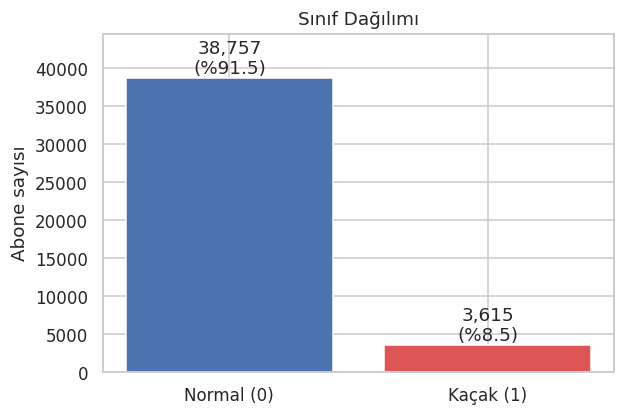

In [4]:
# 2.1 Sınıf dağılımı
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Kaçak (1)'], counts.values, color=['#4C72B0', '#DD5555'])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n(%{100 * v / counts.sum():.1f})',
            ha='center', va='bottom')
ax.set_title('Sınıf Dağılımı')
ax.set_ylabel('Abone sayısı')
ax.set_ylim(0, counts.max() * 1.15)
save_fig('01_class_distribution')
plt.show()

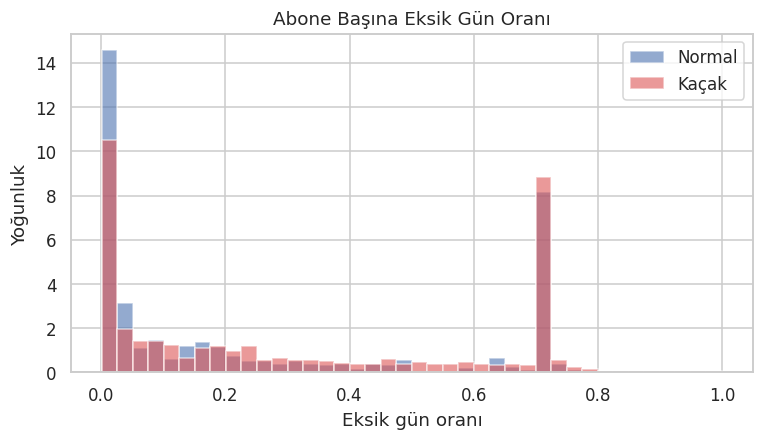

            mean       50%
FLAG                      
Normal  0.250962  0.092843
Kaçak   0.314687  0.213733


In [5]:
# 2.2 Abone başına eksik gün oranı (sınıflara göre)
missing_ratio = X_raw.isna().mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, '#4C72B0', 'Normal'), (1, '#DD5555', 'Kaçak')]:
    ax.hist(missing_ratio[y == label], bins=40, alpha=0.6, density=True, color=color, label=name)
ax.set_title('Abone Başına Eksik Gün Oranı')
ax.set_xlabel('Eksik gün oranı')
ax.set_ylabel('Yoğunluk')
ax.legend()
save_fig('02_missing_ratio')
plt.show()

print(missing_ratio.groupby(y).describe()[['mean', '50%']].rename(index={0: 'Normal', 1: 'Kaçak'}))

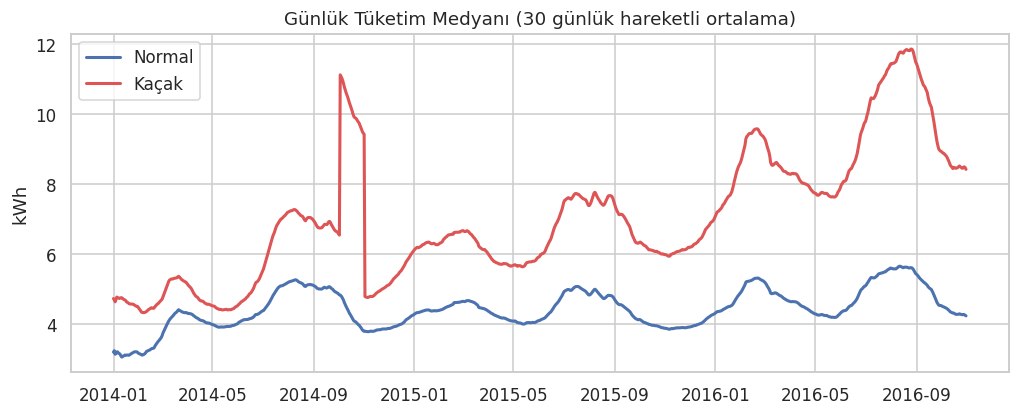

In [6]:
# 2.3 Zaman içinde tipik tüketim (30 günlük hareketli medyan)
fig, ax = plt.subplots(figsize=(11, 4))
for label, color, name in [(0, '#4C72B0', 'Normal'), (1, '#DD5555', 'Kaçak')]:
    series = X_raw[y == label].median(axis=0, skipna=True).rolling(30, min_periods=1).mean()
    ax.plot(series.index, series.values, color=color, label=name, lw=2)
ax.set_title('Günlük Tüketim Medyanı (30 günlük hareketli ortalama)')
ax.set_ylabel('kWh')
ax.legend()
save_fig('03_consumption_over_time')
plt.show()

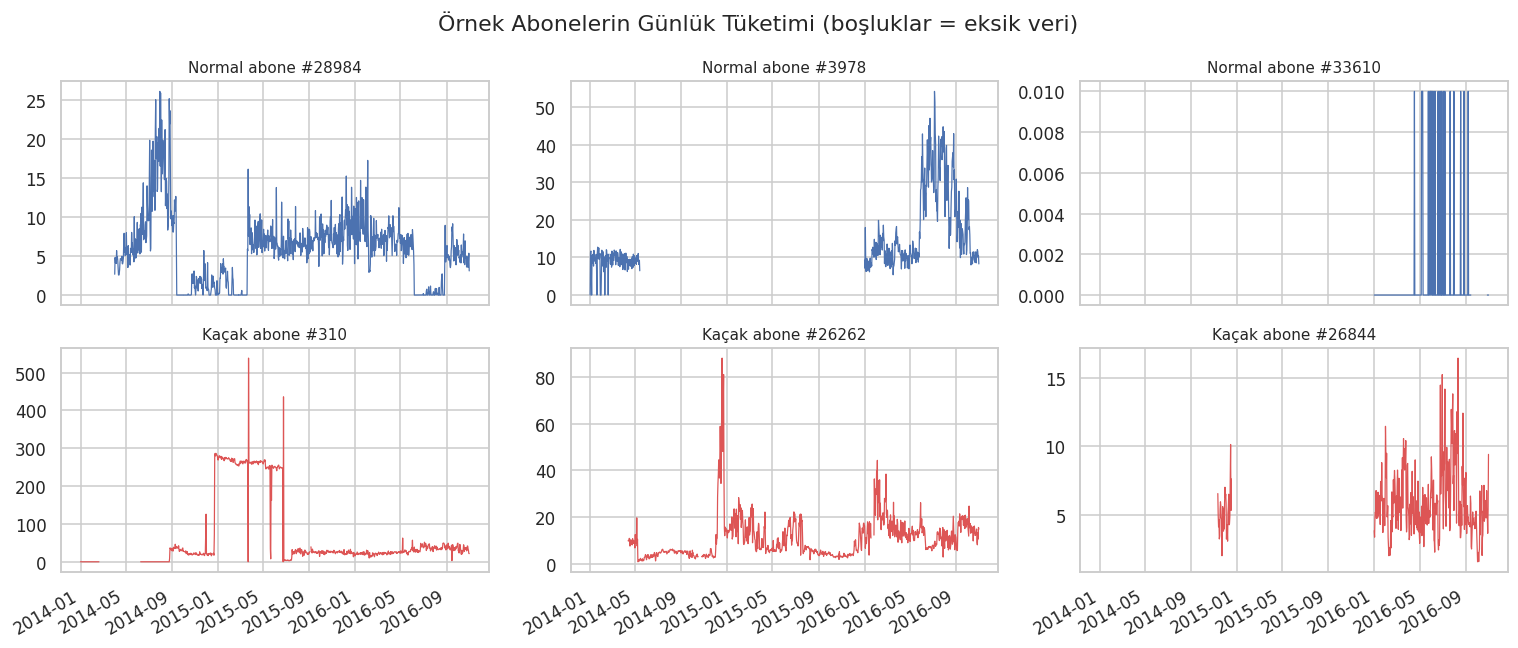

In [7]:
# 2.4 Örnek abone profilleri
rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for row, (label, color, name) in enumerate([(0, '#4C72B0', 'Normal'), (1, '#DD5555', 'Kaçak')]):
    ids = rng.choice(np.where(y == label)[0], 3, replace=False)
    for col, i in enumerate(ids):
        axes[row, col].plot(X_raw.columns, X_raw.iloc[i].values, color=color, lw=0.8)
        axes[row, col].set_title(f'{name} abone #{i}', fontsize=10)
fig.suptitle('Örnek Abonelerin Günlük Tüketimi (boşluklar = eksik veri)')
fig.autofmt_xdate()
plt.tight_layout()
save_fig('04_sample_customers')
plt.show()

## 3. Ön işleme

- **İnterpolasyon `axis=1`:** Her abonenin eksik günü, *kendi* komşu günlerinden doldurulur. (`axis=0` varsayılanı farklı aboneler arasında interpolasyon yapar; bu hem anlamsızdır hem de dosya FLAG'e göre sıralıysa etiket sızıntısına yol açar.)
- Serinin tamamen boş olduğu aboneler 0 ile doldurulur.
- **Uç değerler:** Her abone için `ortalama + 3σ` üzerindeki değerler bu sınıra çekilir (sayaç okuma hatalarını bastırmak için).
- Tüm işlemler satır bazlıdır, train/test ayrımından önce yapılması sızıntı yaratmaz. XGBoost ağaç tabanlı olduğu için ölçeklemeye (MinMaxScaler) gerek yoktur.

In [8]:
X_filled = X_raw.interpolate(axis=1, limit_direction='both').fillna(0)

row_mean = X_filled.mean(axis=1)
row_std = X_filled.std(axis=1)
X_clean = X_filled.clip(upper=row_mean + 3 * row_std, axis=0)

del X_filled
print('Kalan eksik değer:', int(X_clean.isna().sum().sum()))

Kalan eksik değer: 0


## 4. Özellik mühendisliği

Ham günlük değerler (1.000+ kolon) modele bilgi verir ama SHAP açıklamaları saha ekibi için anlamsızdır ("2 Ocak 2014 tüketimi önemli" gibi). Bu yüzden yorumlanabilir özellikler ekliyoruz:

| Özellik | Anlamı |
|---|---|
| `mean`, `std`, `max`, `median`, `cv` | Genel tüketim seviyesi ve değişkenliği |
| `zero_ratio` | Sıfır tüketim olan gün oranı |
| `missing_ratio` | Orijinal veride okunamayan gün oranı |
| `trend_slope` | Tüm dönem boyunca tüketim eğilimi |
| `last_vs_first_ratio` | Son 6 ay / ilk 6 ay ortalaması |
| `sudden_drop_count` | Önceki aya göre %50'den fazla düşüş yaşanan ay sayısı |
| `month_YYYY-MM` | Aylık ortalama tüketim |

In [9]:
def build_features(X_days: pd.DataFrame, missing_ratio: pd.Series) -> pd.DataFrame:
    arr = X_days.values
    eps = 1e-6
    f = pd.DataFrame(index=X_days.index)

    f['mean'] = arr.mean(axis=1)
    f['std'] = arr.std(axis=1)
    f['max'] = arr.max(axis=1)
    f['median'] = np.median(arr, axis=1)
    f['cv'] = f['std'] / (f['mean'] + eps)
    f['zero_ratio'] = (arr == 0).mean(axis=1)
    f['missing_ratio'] = missing_ratio.values

    t = np.arange(arr.shape[1], dtype=float)
    t_c = t - t.mean()
    f['trend_slope'] = (arr - arr.mean(axis=1, keepdims=True)) @ t_c / (t_c ** 2).sum()
    f['last_vs_first_ratio'] = arr[:, -180:].mean(axis=1) / (arr[:, :180].mean(axis=1) + eps)

    # Aylık ortalamalar
    months = X_days.columns.to_period('M')
    unique_months = months.unique()
    monthly = np.column_stack([arr[:, months == m].mean(axis=1) for m in unique_months])
    monthly_df = pd.DataFrame(monthly, index=X_days.index,
                              columns=[f'month_{m}' for m in unique_months])

    prev, nxt = monthly[:, :-1], monthly[:, 1:]
    f['sudden_drop_count'] = ((prev > 0) & (nxt < 0.5 * prev)).sum(axis=1)

    return pd.concat([f, monthly_df], axis=1)

X_eng = build_features(X_clean, missing_ratio)

X_daily = X_clean.copy()
X_daily.columns = X_daily.columns.strftime('day_%Y-%m-%d')
X_all = pd.concat([X_daily, X_eng], axis=1)

print('Günlük özellik:', X_daily.shape[1], '| Türetilmiş özellik:', X_eng.shape[1], '| Toplam:', X_all.shape[1])
X_eng.iloc[:, :10].groupby(y).median().rename(index={0: 'Normal', 1: 'Kaçak'}).T

Günlük özellik: 1034 | Türetilmiş özellik: 44 | Toplam: 1078


FLAG,Normal,Kaçak
mean,5.220449,8.325474
std,2.538892,5.117383
max,14.315129,25.106019
median,4.550000,6.917889
cv,0.493608,0.632715
zero_ratio,0.006770,0.002901
missing_ratio,0.092843,0.213733
trend_slope,0.000215,0.003199
last_vs_first_ratio,1.164018,1.732309
sudden_drop_count,1.000000,1.000000


## 5. Train / Validation / Test ayrımı

- **Test (%20):** Sadece en sonda, bir kez kullanılır.
- **Validation (kalan verinin %20'si):** Model karşılaştırma ve karar eşiği seçimi için.
- Tüm ayrımlar `stratify` ile yapılır, böylece kaçak oranı her sette korunur.

In [10]:
idx = np.arange(len(y))
idx_trval, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
idx_tr, idx_val = train_test_split(idx_trval, test_size=0.2, stratify=y.iloc[idx_trval],
                                   random_state=RANDOM_STATE)

for name, ids in [('Train', idx_tr), ('Validation', idx_val), ('Test', idx_test)]:
    print(f'{name:<11}: {len(ids):>6} abone | kaçak oranı: {y.iloc[ids].mean():.3f}')

Train      :  27117 abone | kaçak oranı: 0.085
Validation :   6780 abone | kaçak oranı: 0.085
Test       :   8475 abone | kaçak oranı: 0.085


## 6. Model deneyleri (validation seti)

Dört kombinasyonu karşılaştırıyoruz: **{Sadece günlük veri, Günlük + türetilmiş özellikler} × {SMOTE, scale_pos_weight}**.
Seçim kriteri: **PR-AUC** (dengesiz veride ROC-AUC'dan daha bilgilendiricidir).



In [11]:
def make_model(scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.5,
        tree_method='hist', eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def fit_model(X_tr, y_tr, strategy):
    if strategy == 'SMOTE':
        X_bal, y_bal = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
        model = make_model()
        model.fit(X_bal, y_bal)
    else:  # scale_pos_weight
        spw = (y_tr == 0).sum() / (y_tr == 1).sum()
        model = make_model(spw)
        model.fit(X_tr, y_tr)
    return model

def precision_at_k(y_true, proba, frac):
    k = max(1, int(len(proba) * frac))
    top = np.argsort(proba)[::-1][:k]
    return np.asarray(y_true)[top].mean()

def evaluate(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'ROC-AUC': roc_auc_score(y_true, proba),
        'PR-AUC': average_precision_score(y_true, proba),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'P@5%': precision_at_k(y_true, proba, 0.05),
        'P@10%': precision_at_k(y_true, proba, 0.10),
    }

feature_sets = {'Günlük': X_daily, 'Günlük + Türetilmiş': X_all}
strategies = ['SMOTE', 'scale_pos_weight']

results, val_probas = [], {}
for fs_name, X_fs in feature_sets.items():
    for strat in strategies:
        key = f'{fs_name} | {strat}'
        print('Eğitiliyor:', key)
        m = fit_model(X_fs.iloc[idx_tr], y.iloc[idx_tr], strat)
        p = m.predict_proba(X_fs.iloc[idx_val])[:, 1]
        val_probas[key] = p
        results.append({'Deney': key, **evaluate(y.iloc[idx_val], p)})

results_df = pd.DataFrame(results).set_index('Deney').sort_values('PR-AUC', ascending=False)
results_df.round(3)

Eğitiliyor: Günlük | SMOTE
Eğitiliyor: Günlük | scale_pos_weight
Eğitiliyor: Günlük + Türetilmiş | SMOTE
Eğitiliyor: Günlük + Türetilmiş | scale_pos_weight


,ROC-AUC,PR-AUC,Precision,Recall,F1,P@5%,P@10%
Deney,,,,,,,
Günlük + Türetilmiş | scale_pos_weight,0.810,0.405,0.413,0.417,0.415,0.513,0.370
Günlük | scale_pos_weight,0.775,0.362,0.403,0.360,0.380,0.499,0.364
Günlük + Türetilmiş | SMOTE,0.771,0.358,0.338,0.363,0.350,0.469,0.323
Günlük | SMOTE,0.722,0.322,0.273,0.431,0.334,0.442,0.320


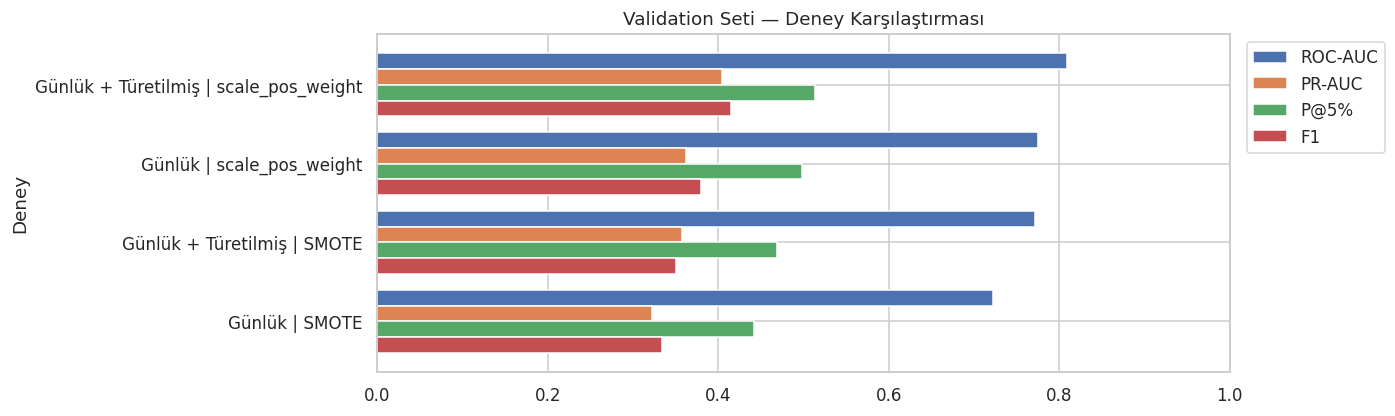

En iyi deney: Günlük + Türetilmiş | scale_pos_weight


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
results_df[['ROC-AUC', 'PR-AUC', 'P@5%', 'F1']].plot.barh(ax=ax, width=0.8)
ax.set_title('Validation Seti — Deney Karşılaştırması')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
save_fig('05_experiment_comparison')
plt.show()

best_key = results_df.index[0]
best_fs, best_strat = [s.strip() for s in best_key.split('|')]
print('En iyi deney:', best_key)

## 7. Karar eşiği seçimi (validation seti)

Varsayılan 0.5 eşiği keyfidir. Validation setinde **F1'i maksimize eden** eşiği seçiyoruz.
Gerçek hayatta eşik, saha ekibinin denetim kapasitesine göre de belirlenebilir (bkz. Bölüm 9, Precision@k).

In [13]:
p_val = val_probas[best_key]
prec, rec, thr = precision_recall_curve(y.iloc[idx_val], p_val)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_threshold = float(thr[np.argmax(f1s)])
print(f'Seçilen eşik: {best_threshold:.3f} (validation F1 = {f1s.max():.3f})')

Seçilen eşik: 0.500 (validation F1 = 0.415)


## 8. Final model ve test seti değerlendirmesi

En iyi yapılandırma train + validation verisiyle yeniden eğitilir ve **yalnızca bir kez** test setinde değerlendirilir.

In [14]:
X_best = feature_sets[best_fs]
final_model = fit_model(X_best.iloc[idx_trval], y.iloc[idx_trval], best_strat)

X_test = X_best.iloc[idx_test]
y_test = y.iloc[idx_test]
p_test = final_model.predict_proba(X_test)[:, 1]
y_pred = (p_test >= best_threshold).astype(int)

test_summary = pd.DataFrame({
    'Eşik = 0.5': evaluate(y_test, p_test, 0.5),
    f'Eşik = {best_threshold:.2f} (seçilen)': evaluate(y_test, p_test, best_threshold),
}).T
print(test_summary.round(3).to_string())
print('\n', classification_report(y_test, y_pred, target_names=['Normal', 'Kaçak'], digits=3))

                       ROC-AUC  PR-AUC  Precision  Recall     F1   P@5%  P@10%
Eşik = 0.5               0.824   0.429      0.403   0.479  0.438  0.537  0.407
Eşik = 0.50 (seçilen)    0.824   0.429      0.403   0.479  0.438  0.537  0.407

               precision    recall  f1-score   support

      Normal      0.951     0.934     0.942      7752
       Kaçak      0.403     0.479     0.438       723

    accuracy                          0.895      8475
   macro avg      0.677     0.706     0.690      8475
weighted avg      0.904     0.895     0.899      8475



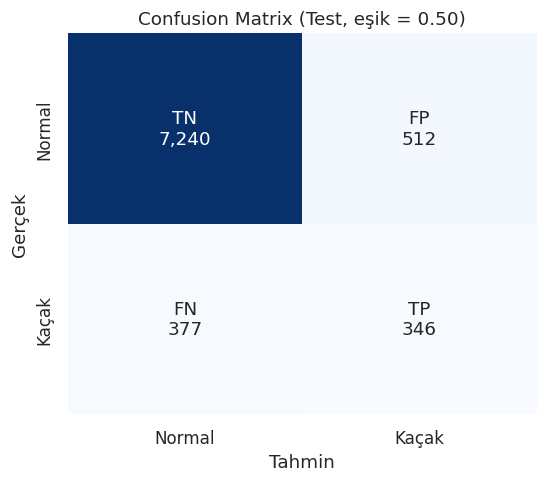

In [15]:
# 8.1 Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = np.array([[f'TN\n{cm[0,0]:,}', f'FP\n{cm[0,1]:,}'],
                   [f'FN\n{cm[1,0]:,}', f'TP\n{cm[1,1]:,}']])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Normal', 'Kaçak'], yticklabels=['Normal', 'Kaçak'], annot_kws={'size': 12})
ax.set_xlabel('Tahmin')
ax.set_ylabel('Gerçek')
ax.set_title(f'Confusion Matrix (Test, eşik = {best_threshold:.2f})')
save_fig('06_confusion_matrix')
plt.show()

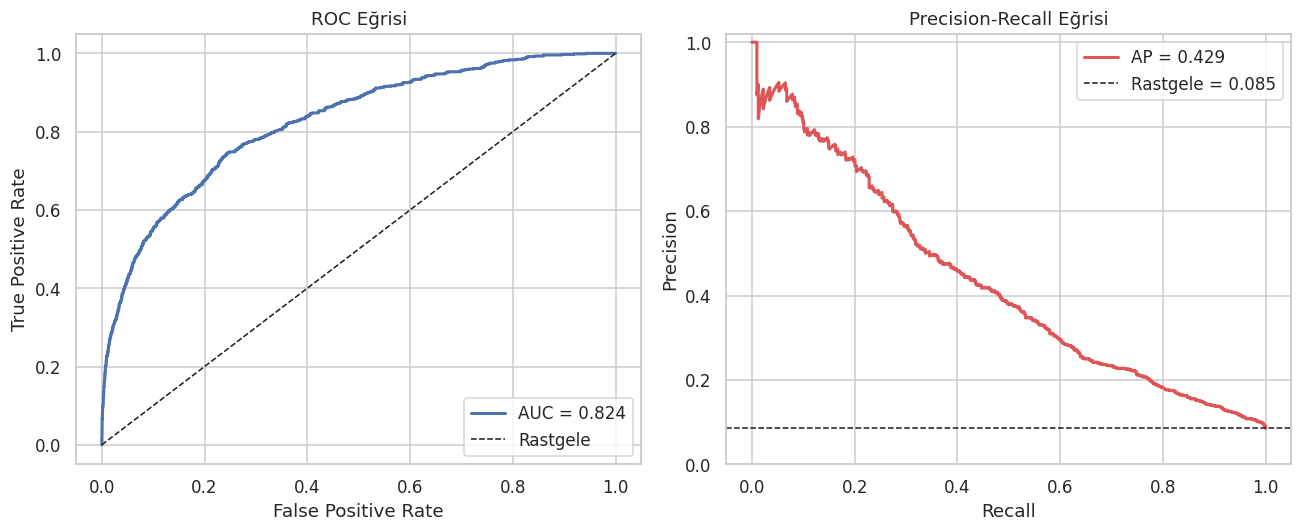

In [16]:
# 8.2 ROC ve Precision-Recall eğrileri
fpr, tpr, _ = roc_curve(y_test, p_test)
prec_t, rec_t, _ = precision_recall_curve(y_test, p_test)
base_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_test, p_test):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Eğrisi')
axes[0].legend(loc='lower right')

axes[1].plot(rec_t, prec_t, lw=2, color='#DD5555',
             label=f'AP = {average_precision_score(y_test, p_test):.3f}')
axes[1].axhline(base_rate, color='k', ls='--', lw=1, label=f'Rastgele = {base_rate:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Eğrisi', ylim=(0, 1.02))
axes[1].legend(loc='upper right')
plt.tight_layout()
save_fig('07_roc_pr_curves')
plt.show()

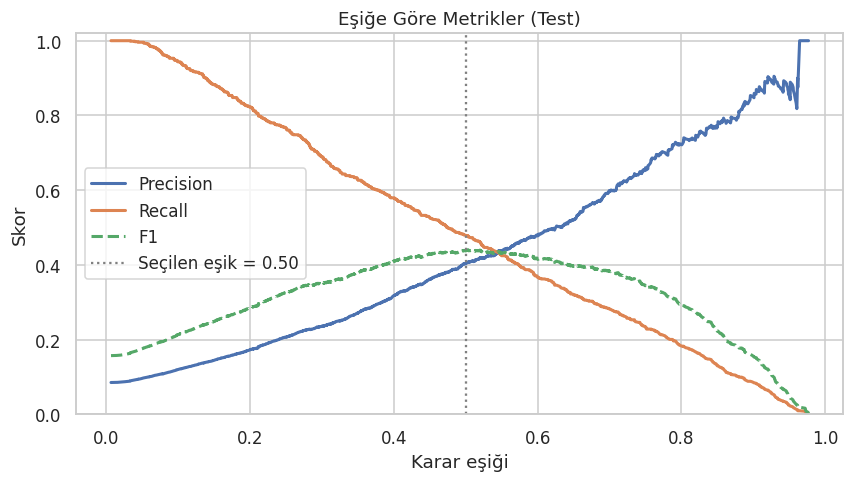

In [17]:
# 8.3 Eşiğe göre Precision / Recall / F1
prec_c, rec_c, thr_c = precision_recall_curve(y_test, p_test)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thr_c, prec_c[:-1], label='Precision', lw=2)
ax.plot(thr_c, rec_c[:-1], label='Recall', lw=2)
ax.plot(thr_c, f1_c, label='F1', lw=2, ls='--')
ax.axvline(best_threshold, color='gray', ls=':', label=f'Seçilen eşik = {best_threshold:.2f}')
ax.set(xlabel='Karar eşiği', ylabel='Skor', title='Eşiğe Göre Metrikler (Test)', ylim=(0, 1.02))
ax.legend()
save_fig('08_threshold_analysis')
plt.show()

## 9. Saha operasyonu perspektifi: Kümülatif kazanç (Lift)

Soru: *Aboneleri risk skoruna göre sıralayıp en riskli %X'ini denetlersek, kaçakçıların yüzde kaçını yakalarız?*
Rastgele denetimde bu oran doğrusal artar (köşegen). Model eğrisi köşegenin ne kadar üstündeyse, saha ekiplerinin zamanı o kadar verimli kullanılır.

Test setinde (8.475 abone, rastgele denetimde isabet oranı %8.5) elde edilen sonuçlar:

| Denetlenen abone | Denetimlerde isabet oranı | Rastgeleye göre | Yakalanan kaçakların oranı |
|---|---|---|---|
| En riskli %5 | %53.7 | 6.3 kat | %31.4 |
| En riskli %10 | %40.7 | 4.8 kat | %47.7 |
| En riskli %20 | %27.0 | 3.2 kat | %63.2 |

Bu tablo, denetim kapasitesine göre karar vermek için kullanılabilir: kapasite kısıtlıysa en riskli %5'e odaklanmak isabeti en üst düzeye çıkarır, daha geniş kapsam isteniyorsa en riskli %20 denetlenerek kaçakların yaklaşık üçte ikisine ulaşılabilir.

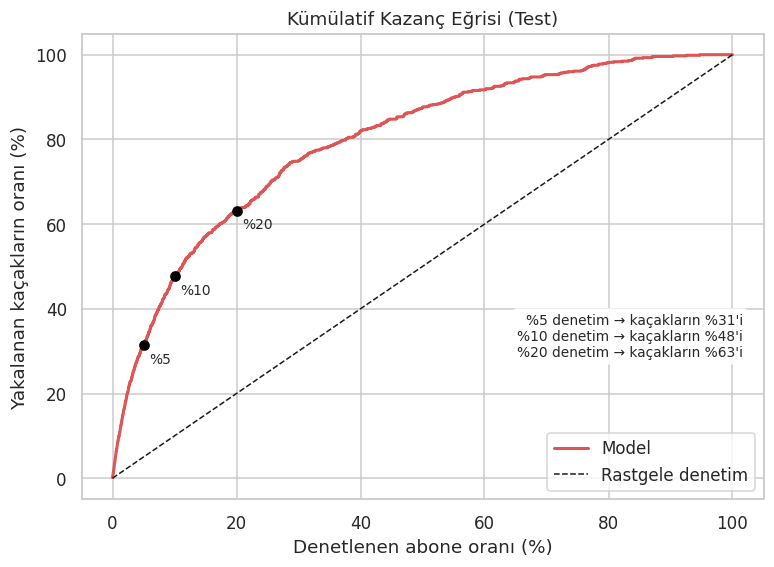

Rastgele denetimde isabet oranı: %8.5
En riskli % 5 denetlenirse: isabet %53.7 (rastgelenin 6.3 katı), kaçakların %31.4'i yakalanır
En riskli %10 denetlenirse: isabet %40.7 (rastgelenin 4.8 katı), kaçakların %47.7'i yakalanır
En riskli %20 denetlenirse: isabet %27.0 (rastgelenin 3.2 katı), kaçakların %63.2'i yakalanır


In [18]:
order = np.argsort(p_test)[::-1]
y_sorted = y_test.values[order]
frac_inspected = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
frac_caught = np.cumsum(y_sorted) / y_sorted.sum()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(frac_inspected * 100, frac_caught * 100, lw=2, color='#DD5555', label='Model')
ax.plot([0, 100], [0, 100], 'k--', lw=1, label='Rastgele denetim')
summary_lines = []
for pct in [5, 10, 20]:
    i = int(len(y_sorted) * pct / 100) - 1
    ax.scatter(pct, frac_caught[i] * 100, color='black', zorder=5)
    ax.annotate(f'%{pct}', (pct, frac_caught[i] * 100), xytext=(4, -12),
                textcoords='offset points', fontsize=9)
    summary_lines.append(f'%{pct} denetim → kaçakların %{frac_caught[i]*100:.0f}\'i')
ax.text(0.97, 0.30, '\n'.join(summary_lines), transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.set(xlabel='Denetlenen abone oranı (%)', ylabel='Yakalanan kaçakların oranı (%)',
       title='Kümülatif Kazanç Eğrisi (Test)')
ax.legend(loc='lower right')
save_fig('09_cumulative_gain')
plt.show()

print(f'Rastgele denetimde isabet oranı: %{base_rate*100:.1f}')
for pct in [0.05, 0.10, 0.20]:
    p_at = precision_at_k(y_test, p_test, pct)
    caught = frac_caught[int(len(y_sorted) * pct) - 1]
    print(f'En riskli %{int(pct*100):>2} denetlenirse: isabet %{p_at*100:.1f} '
          f'(rastgelenin {p_at/base_rate:.1f} katı), kaçakların %{caught*100:.1f}\'i yakalanır')

## 10. Açıklanabilirlik (SHAP)

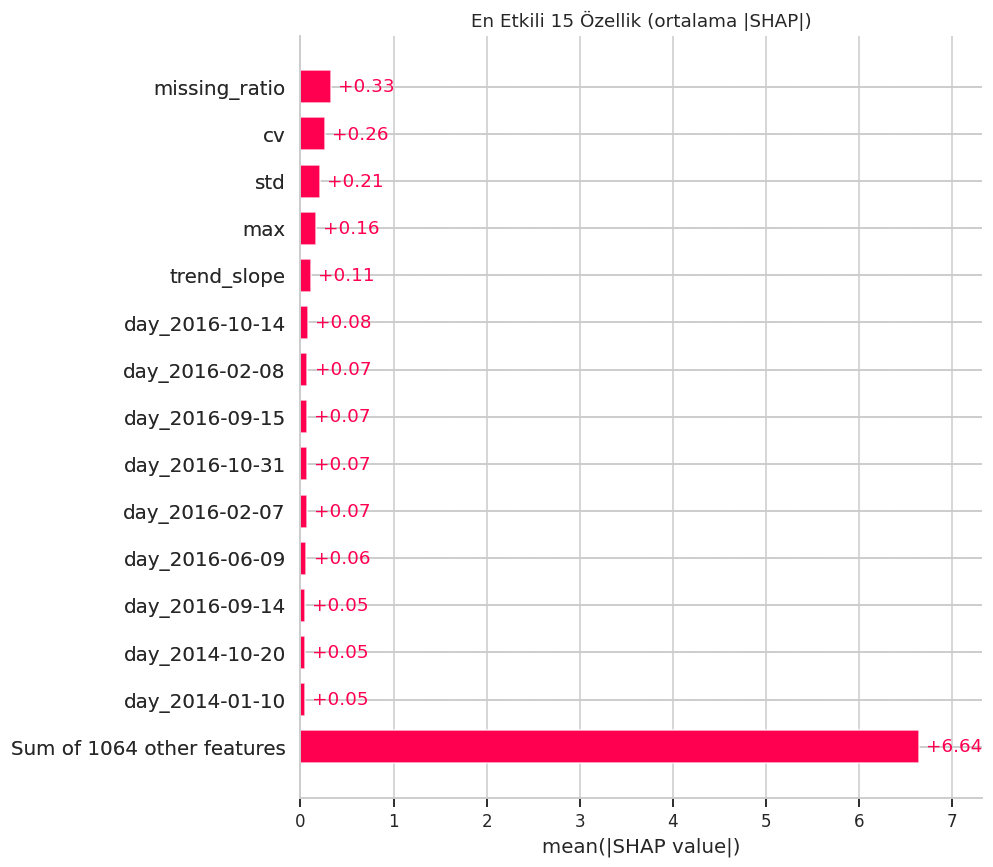

In [19]:
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_shap)

# 10.1 Genel önem sıralaması
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('En Etkili 15 Özellik (ortalama |SHAP|)')
save_fig('10_shap_bar')
plt.show()

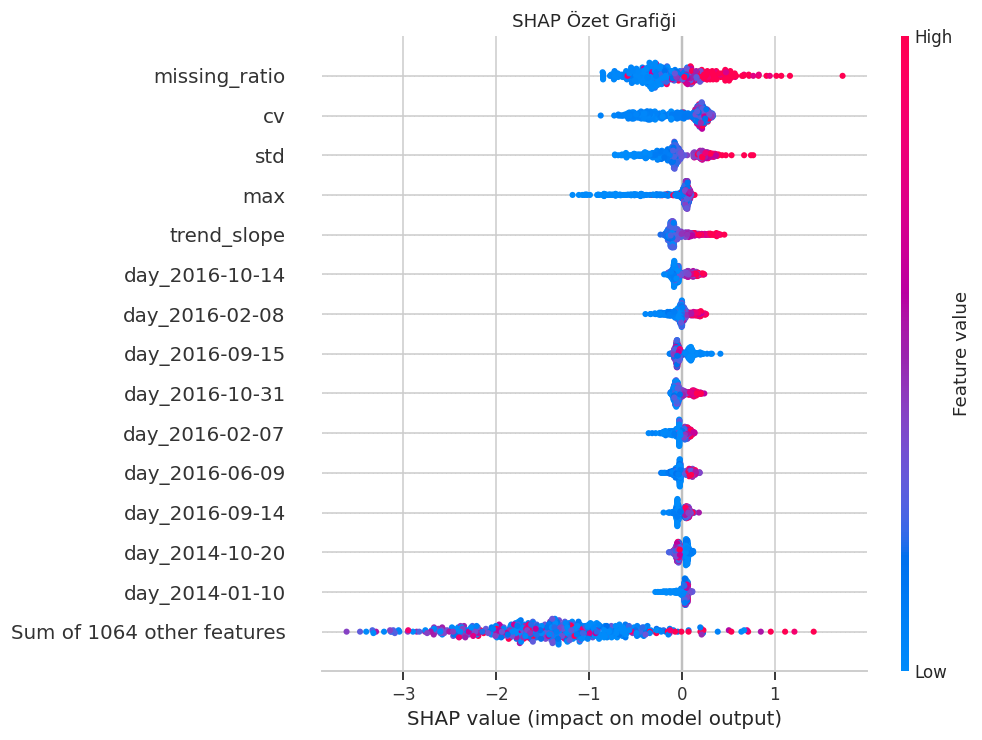

In [20]:
# 10.2 Özellik değerlerinin tahmine etkisinin yönü
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Özet Grafiği')
save_fig('11_shap_beeswarm')
plt.show()

Abone: 66329AC9964AB7B12DEDC9F63420D9BC | Risk skoru: 0.977 | Gerçek etiket: 1


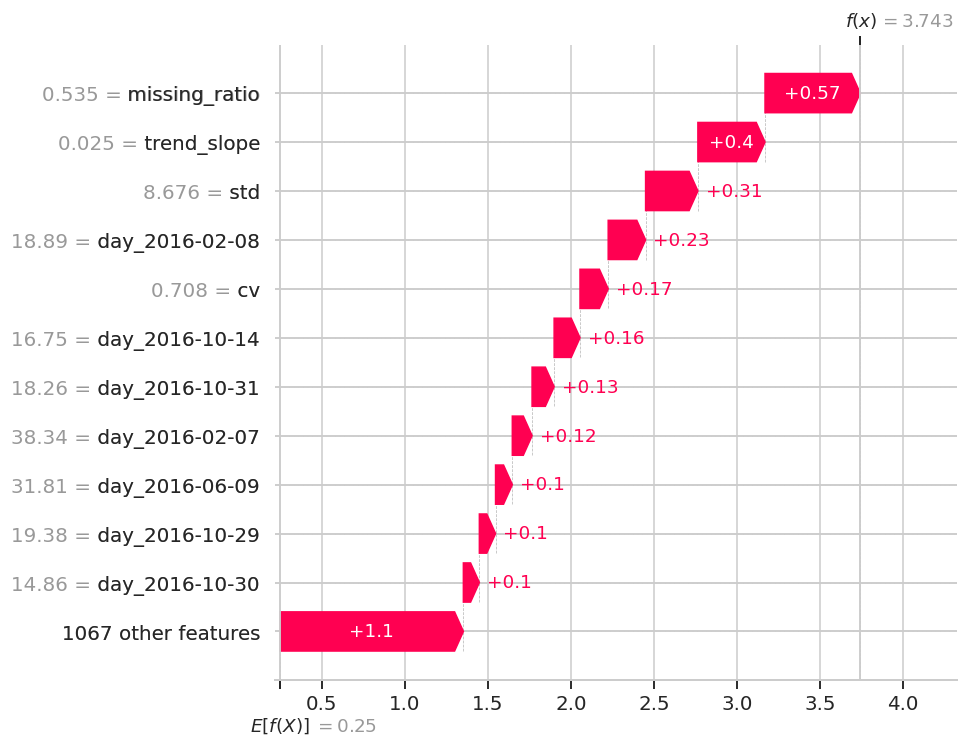

In [21]:
# 10.3 Tek bir abone için karar açıklaması (örneklemdeki en riskli abone)
risk_in_sample = final_model.predict_proba(X_shap)[:, 1]
i_top = int(np.argmax(risk_in_sample))
print(f'Abone: {cons_no.loc[X_shap.index[i_top]]} | Risk skoru: {risk_in_sample[i_top]:.3f} '
      f'| Gerçek etiket: {y.loc[X_shap.index[i_top]]}')

plt.figure()
shap.plots.waterfall(shap_values[i_top], max_display=12, show=False)
save_fig('12_shap_waterfall_top_customer')
plt.show()

## 11. Karar destek çıktısı: Risk skoru listesi

Test setindeki aboneler risk skoruna göre sıralanır ve üç seviyeye ayrılır:
**Yüksek** (en riskli %5), **Orta** (sonraki %10), **Düşük** (geri kalan).

In [22]:
risk_df = pd.DataFrame({
    'CONS_NO': cons_no.iloc[idx_test].values,
    'risk_skoru': p_test,
    'gercek_FLAG': y_test.values,
}).sort_values('risk_skoru', ascending=False).reset_index(drop=True)

pct_rank = np.arange(1, len(risk_df) + 1) / len(risk_df)
risk_df['risk_seviyesi'] = np.select([pct_rank <= 0.05, pct_rank <= 0.15], ['Yüksek', 'Orta'], 'Düşük')

risk_df.to_csv('risk_scores_test.csv', index=False)
print(risk_df.groupby('risk_seviyesi', sort=False)['gercek_FLAG'].agg(['count', 'mean'])
      .rename(columns={'count': 'abone', 'mean': 'gerçek kaçak oranı'}).round(3))
risk_df.head(20)

               abone  gerçek kaçak oranı
risk_seviyesi                           
Yüksek           423               0.537
Orta             848               0.218
Düşük           7204               0.043


,CONS_NO,risk_skoru,gercek_FLAG,risk_seviyesi
0,66329AC9964AB7B12DEDC9F63420D9BC,0.976866,1,Yüksek
1,825E19825195633229E0E0BD91F412AB,0.976293,1,Yüksek
2,397C84F9F2AEF73869F12D82B3D54DE3,0.973383,1,Yüksek
3,FF2D183CFEE4E2372324887BE3B9ABBE,0.972876,1,Yüksek
4,35C0690E0AF7174AC19F5644DC5233A0,0.972682,1,Yüksek
5,F1D26619E4BC428924BAF5261F705D18,0.972202,1,Yüksek
6,1B173C1A3A2EEF026D089EE150A5AA51,0.964519,1,Yüksek
7,6AF38DF12C3E0B41D71C838E30022B95,0.962004,0,Yüksek
8,0C72D35CD3E76A966E65946FB1FA912D,0.961724,1,Yüksek
9,A0A399DE0D59698E41BE2E4C6AAE3DE7,0.961697,1,Yüksek


## 12. Sonuçlar ve iş çıktıları

### Model seçimi (validation seti)

| Deney | ROC-AUC | PR-AUC | F1 | P@5% |
|---|---|---|---|---|
| **Günlük + Türetilmiş, scale_pos_weight** | **0.810** | **0.405** | **0.415** | **0.513** |
| Günlük, scale_pos_weight | 0.775 | 0.362 | 0.380 | 0.499 |
| Günlük + Türetilmiş, SMOTE | 0.771 | 0.358 | 0.350 | 0.469 |
| Günlük, SMOTE | 0.722 | 0.322 | 0.334 | 0.442 |

- **`scale_pos_weight`, her iki özellik setinde de SMOTE'tan daha iyi sonuç verdi.** 1.000+ boyutlu zaman serilerinde SMOTE, iki abonenin tüketim eğrisi arasında interpolasyon yaparak gerçekçi olmayan sentetik aboneler üretmektedir; sınıf ağırlıklandırma ise gerçek veriye sadık kalır.
- **Türetilmiş özellikler her iki yöntemde de performansı artırdı** (en iyi yapılandırmada PR-AUC 0.362 → 0.405).

### Test seti sonuçları

Final model (Günlük + Türetilmiş, scale_pos_weight) train + validation verisiyle yeniden eğitildi ve test setinde bir kez değerlendirildi. Validation setinde F1'i maksimize eden eşik, varsayılan 0.5 ile örtüştü.

| Metrik | Değer | Rastgele model |
|---|---|---|
| ROC-AUC | 0.824 | 0.500 |
| PR-AUC | 0.429 | 0.085 |
| Precision (Kaçak) | 0.403 | 0.085 |
| Recall (Kaçak) | 0.479 | — |
| F1 (Kaçak) | 0.438 | — |

- Test setindeki 723 kaçak abonenin **yaklaşık 346'sı yakalandı**.
- Model yaklaşık 859 aboneye alarm verdi; bunların **her 100'ünden yaklaşık 40'ı gerçekten kaçak**. Aynı sayıda adres rastgele denetlenseydi yaklaşık 73 kaçak bulunacaktı (**≈ 4.7 kat verim**).
- **Accuracy neden raporlanmıyor?** Modelin accuracy değeri 0.895'tir. Herkese "normal" diyen ve hiçbir kaçakçıyı bulamayan naif bir model %91.5 accuracy alır. Yani bu problemde accuracy, işe yarayan bir modeli işe yaramayandan daha kötü gösterir.

### Karar destek çıktısı: Risk seviyeleri

| Risk seviyesi | Abone sayısı | Gerçek kaçak oranı |
|---|---|---|
| Yüksek (en riskli %5) | 423 | %53.7 |
| Orta (sonraki %10) | 848 | %21.8 |
| Düşük (kalan %85) | 7.204 | %4.3 |

Seviyeler net biçimde ayrışmaktadır. "Düşük" gruptaki kaçak oranı genel ortalamanın (%8.5) yarısıdır; bu, modelin yalnızca riskli aboneleri değil, denetime gerek olmayan aboneleri de makul ölçüde ayırt ettiğini gösterir. Tüm test aboneleri `risk_scores_test.csv` dosyasına kaydedilmiştir.

### Açıklanabilirlik (SHAP)

- **En etkili beş özelliğin tamamı türetilmiş özelliklerdir:** `missing_ratio`, `cv`, `std`, `max`, `trend_slope`.
- **Riski artıran örüntüler:** okunamayan gün oranının yüksek olması, tüketimin dalgalı olması ve zaman içinde artış eğilimi göstermesi. Düşük maksimum tüketim ise güçlü bir "normal" sinyalidir.
- Günlük özellikler arasında en etkili olanlar çoğunlukla 2016'nın son aylarına aittir; model yakın dönem tüketimine ağırlık vermektedir.
- Buna karşın kalan 1.064 özelliğin toplam katkısı tekil özelliklerden çok daha büyüktür; modelin kararı binlerce günlük değere dağılmıştır. Bu durum açıklanabilirliği sınırlamaktadır.
- Not: SHAP değerleri olasılık değil, **log-odds** cinsindendir (ör. waterfall grafiğindeki f(x) = 3.74, 0.977 risk skoruna karşılık gelir).

### Sınırlamalar

- **Etiket gürültüsü:** Etiketler geçmiş denetimlere dayanır; tespit edilmemiş kaçakçılar "normal" etiketli olabilir.
- **Olası seçilim yanlılığı:** Kaçak aboneler daha yüksek ve daha dalgalı tüketime sahiptir. Bu, büyük tüketicilerin kaçağa daha yatkın olmasından kaynaklanabileceği gibi, denetim ekiplerinin bu tür aboneleri daha sık denetlemesinden de kaynaklanabilir.
- **`missing_ratio` bir kısayol olabilir:** En güçlü sinyal okunamayan gün oranıdır. Bu, sayaç müdahalesinin gerçek bir izi olabileceği gibi, okunamayan sayaçların daha sık denetlenmesinden doğan bir veri toplama etkisi de olabilir. İkinci durumda model "kaçakçıyı" değil, "denetlenme olasılığı yüksek aboneyi" öğreniyor olabilir.
- **Uzun eksik dönemler:** Aylarca süren boşluklar interpolasyonla doldurulmuştur; bu kısa boşluklar için makul, uzun boşluklar için yapay bir tahmindir.
- **Veri kalitesi:** Veride neredeyse hiç okuma içermeyen aboneler bulunmaktadır; bunlar metrikleri bir miktar etkileyebilir.
- **Genellenebilirlik:** Veri tek bir bölgeye ve döneme aittir; başka şebekelerde test edilmemiştir.
- **Bağlam eksikliği:** Model yalnızca tüketim verisini kullanır; hava durumu, tatiller ve abone tipi gibi bilgiler yanlış alarmları azaltabilir.

### Önceki / referans yaklaşımlardan farklar

- **İnterpolasyon ekseni düzeltildi:** Eksik günler, aboneler arasında (`axis=0`) değil, her abonenin kendi zaman serisi boyunca (`axis=1`) dolduruldu. Veri dosyasının satır sırası etiketle ilişkili olduğundan (dosyanın son %10'unda hiç kaçak abone yoktur), satırlar arası doldurma hem anlamsız hem de potansiyel olarak yanıltıcıdır.
- **Train/test sızıntısı giderildi:** Tüm veri üzerinde fit edilen MinMaxScaler ve kolon ortalamasıyla doldurma kaldırıldı. Eksik değer doldurma ve uç değer sınırlama yalnızca her abonenin kendi verisi kullanılarak (satır bazında) yapılıyor; ağaç tabanlı model ölçeklemeye ihtiyaç duymadığı için ölçekleme adımı çıkarıldı.
- **Ayrı validation seti:** Model seçimi ve eşik ayarı validation setinde yapıldı; test setine yalnızca bir kez bakıldı.
- **Saha odaklı değerlendirme:** Accuracy yerine PR-AUC, Precision@k ve kümülatif kazanç kullanıldı.
- **Sonuçların karşılaştırılması:** Referans yaklaşım yaklaşık 0.65 precision/recall raporlarken, düzeltilmiş pipeline 0.40 precision ve 0.48 recall elde etmektedir. Aradaki farkın hangi değişiklikten kaynaklandığı bu çalışmada ayrıca ölçülmemiştir; ancak yeni sonuçlar metodolojik olarak doğru ve sızıntısız bir değerlendirmeyi yansıtmaktadır.